Notebook explaining step by step how we build the `compute_likelihood_map` function.

In [1]:
from retinotopy import *
args = Params()

----------------------------------------------------------------------------------
On date 2024-05-14, Running learning on host Ahsoka with device cpu, pytoch==2.2.2
----------------------------------------------------------------------------------
Welcome on macOS-14.5-x86_64-i386-64bit


# Likelihood map on a test image

In [2]:
from torchvision.io import read_image

true_label = 'jaguar'
image_url = './imgs/jaguar_5.jpg'
image_url = './imgs/jaguar.jpg'

true_label = 'tree_frog'
image_url = './imgs/frog.jpg'

alpha = .5
full_image = read_image(image_url)/255
full_image_np = torch.movedim(full_image, (1, 2, 0), (0, 1, 2)).numpy()
print(f"{type(full_image) = }, {full_image.dtype = }, {full_image.shape = }")

type(full_image) = <class 'torch.Tensor'>, full_image.dtype = torch.float32, full_image.shape = torch.Size([3, 375, 500])


In [3]:
full_image.min(), full_image.max()

(tensor(0.), tensor(1.))

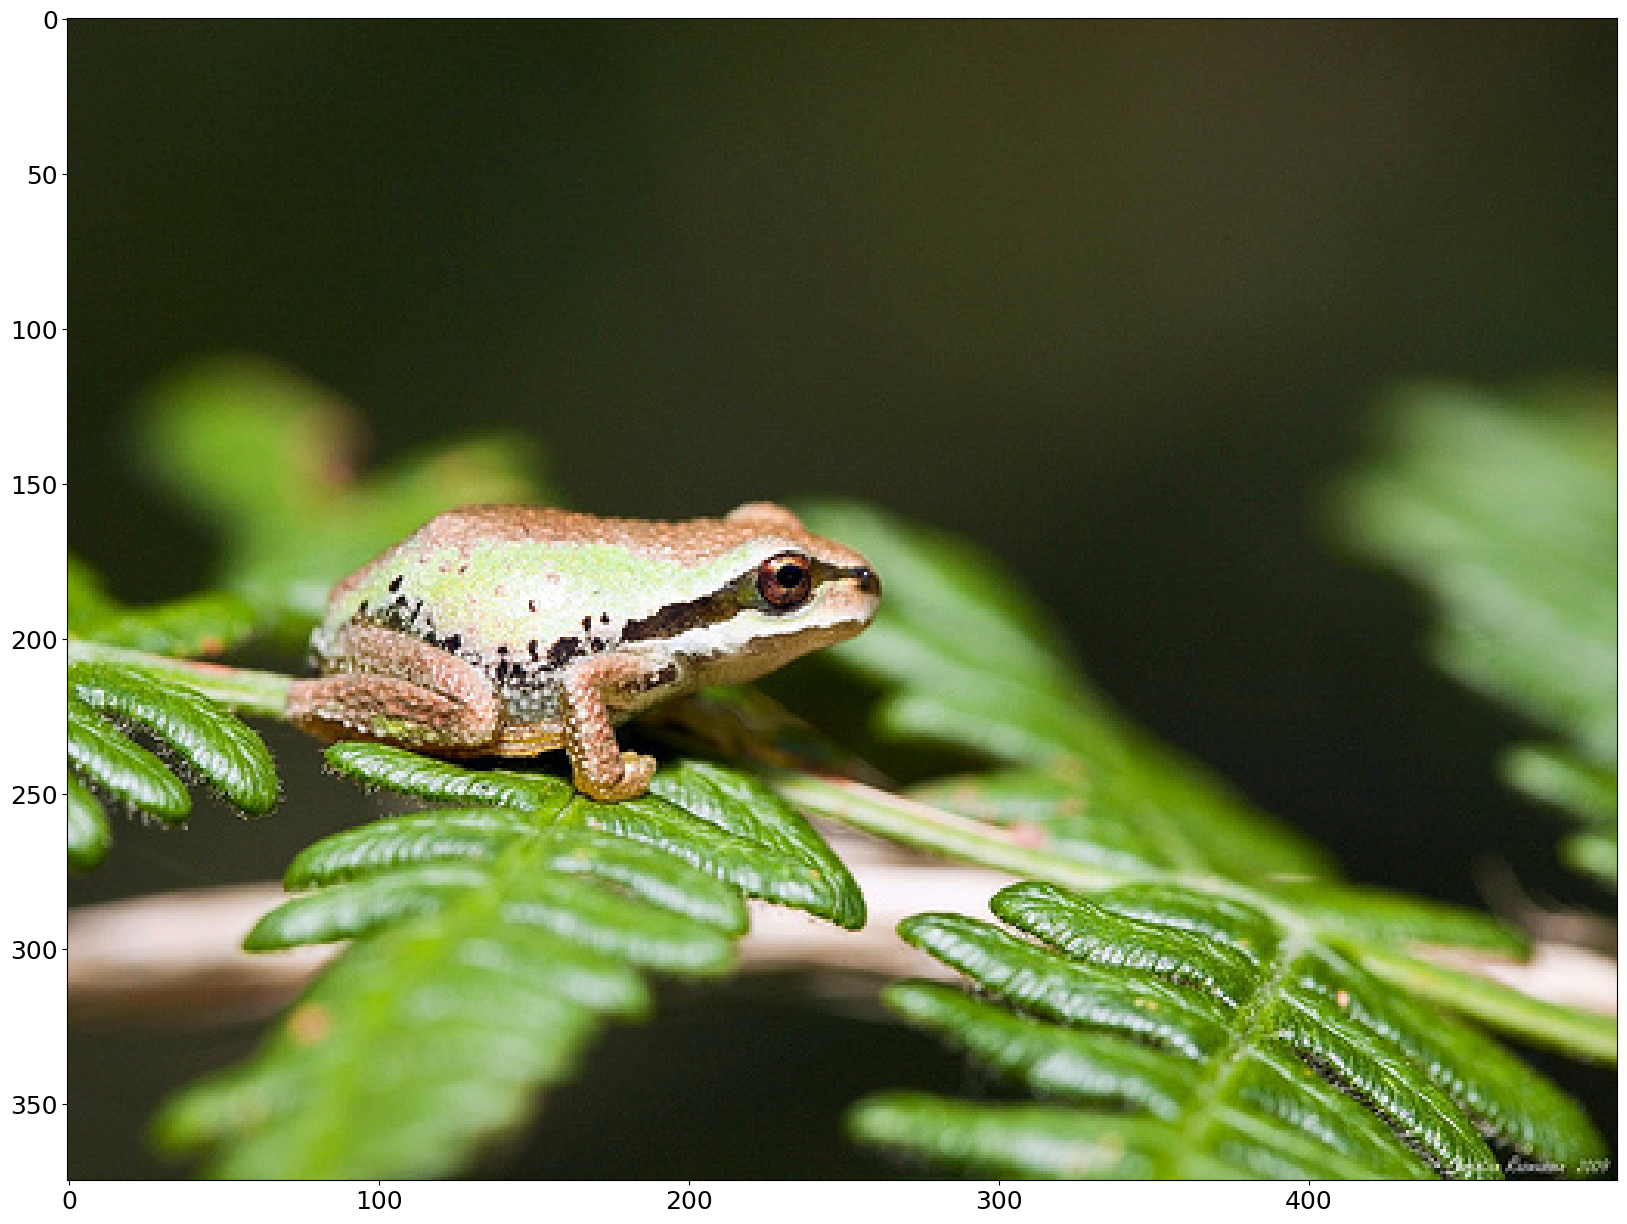

In [4]:
fig, ax = plt.subplots(figsize=(fig_width, fig_width))
ax.imshow(full_image_np)
# ax.set_xticks([])
# ax.set_yticks([])  
fig.set_facecolor(color='white')

In [5]:
args.do_polar = True
data_transform = get_transforms(args)
out = data_transform(full_image)
print(f"{type(out) = }, {out.dtype = }, {out.shape = }")

type(out) = <class 'torch.Tensor'>, out.dtype = torch.float32, out.shape = torch.Size([3, 224, 224])


## making a grid

### first strategy: valid boxes

In [6]:
resolution = (11, 11) # how many fixation points to use
size_ratio = 0.3 # how much of the image to use relative to radius
N_fixations = np.prod(resolution)

three, H, W = full_image.shape
max_size = np.max((H, W))
min_size = np.min((H, W))
box_size = int(min_size*size_ratio)

if H < W:
    shift = (0, (W-H)/2)
else:
    shift = ((H-W)/2, 0)
min_size, max_size, shift[0], shift[1], box_size

(375, 500, 0, 62.5, 112)

In [7]:
pos_h = np.linspace(shift[0]+box_size/2, min_size+shift[0]-box_size/2, resolution[0], endpoint=True)
pos_w = np.linspace(shift[1]+box_size/2, min_size+shift[1]-box_size/2, resolution[1], endpoint=True)
pos_h, pos_w

(array([ 56. ,  82.3, 108.6, 134.9, 161.2, 187.5, 213.8, 240.1, 266.4,
        292.7, 319. ]),
 array([118.5, 144.8, 171.1, 197.4, 223.7, 250. , 276.3, 302.6, 328.9,
        355.2, 381.5]))

### second strategy: brutal

In [8]:
aspect_ratio = H/W
N_fixations = np.prod(resolution)
resolution = (int(np.sqrt(N_fixations*aspect_ratio)), int(np.sqrt(N_fixations/aspect_ratio)))
N_fixations = np.prod(resolution)
resolution

(9, 12)

In [9]:
pos_h = np.linspace(0, H, resolution[0]+2, endpoint=True)[1:-1]
pos_w = np.linspace(0, W, resolution[1]+2, endpoint=True)[1:-1]
pos_h, pos_w

(array([ 37.5,  75. , 112.5, 150. , 187.5, 225. , 262.5, 300. , 337.5]),
 array([ 38.46153846,  76.92307692, 115.38461538, 153.84615385,
        192.30769231, 230.76923077, 269.23076923, 307.69230769,
        346.15384615, 384.61538462, 423.07692308, 461.53846154]))

In [10]:
pos_H, pos_W = np.meshgrid(pos_h, pos_w)
pos_H.shape, pos_W.shape

((12, 9), (12, 9))

In [11]:
# fixations= np.array(list(p)).T
# fixations.shape

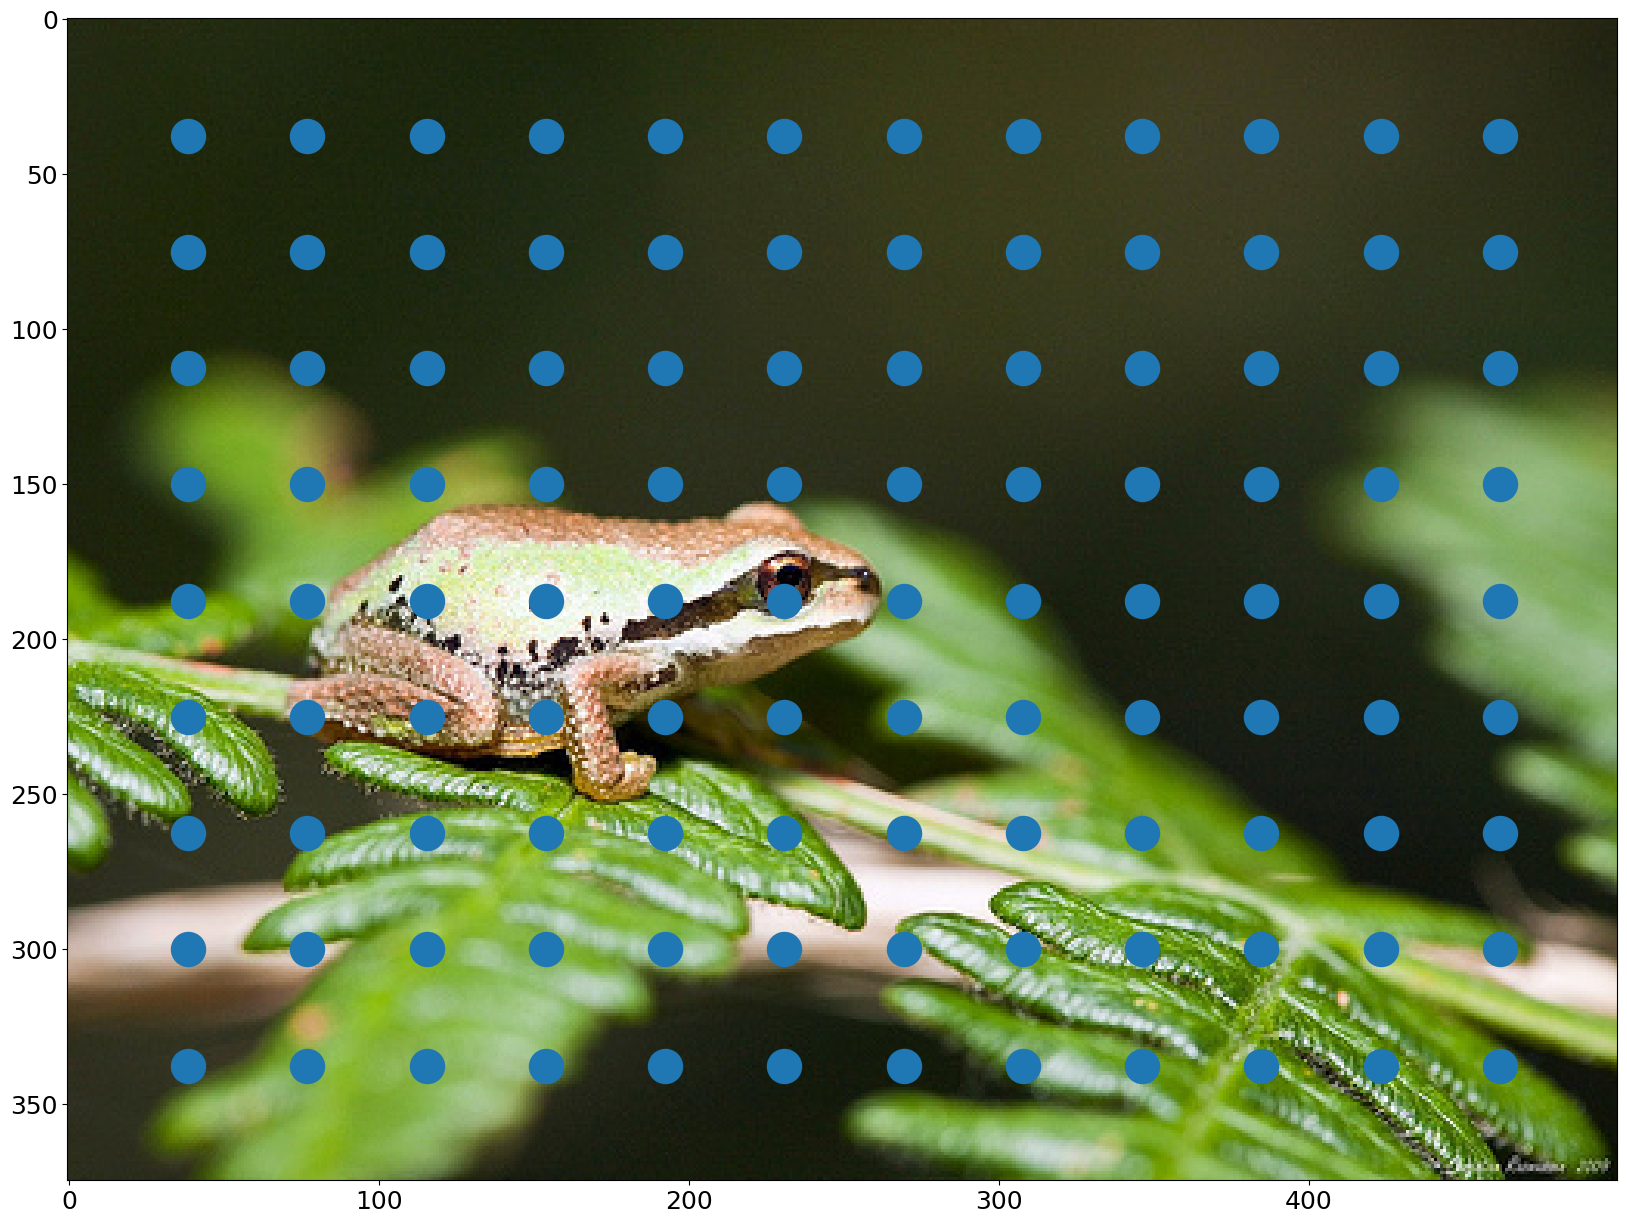

In [12]:
fig, ax = plt.subplots(figsize=(fig_width, fig_width))
ax.imshow(full_image_np)
# ax.set_xticks([])
ax.scatter(pos_W.ravel(), pos_H.ravel(), s=600)
# ax.set_yticks([])  
fig.set_facecolor(color='white')

In [13]:
args.image_size = box_size
data_transform = get_transforms(args)

In [14]:
# full_image[:, h-box_size//2:h+box_size//2, w-box_size//2:w+box_size//2].shape

In [15]:
# data_transform(full_image[:, h-box_size//2:h+box_size//2, w-box_size//2:w+box_size//2]).shape

do_polar=True
do_polar=False


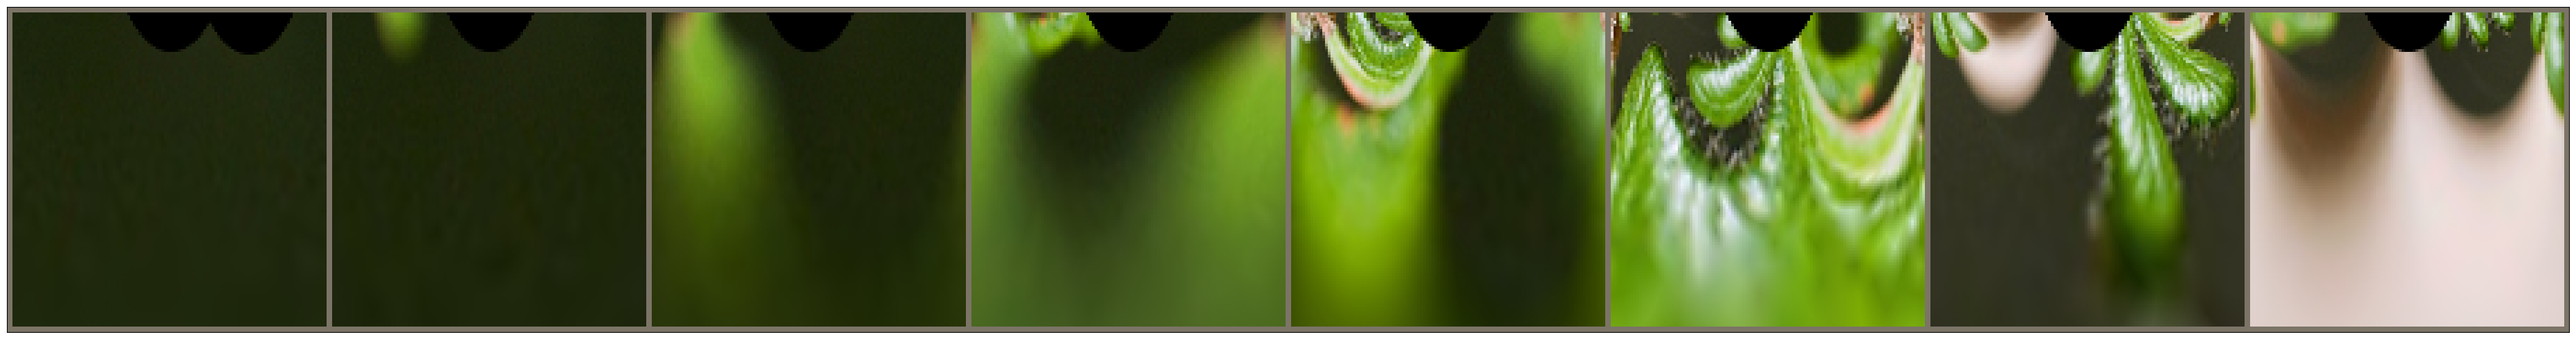

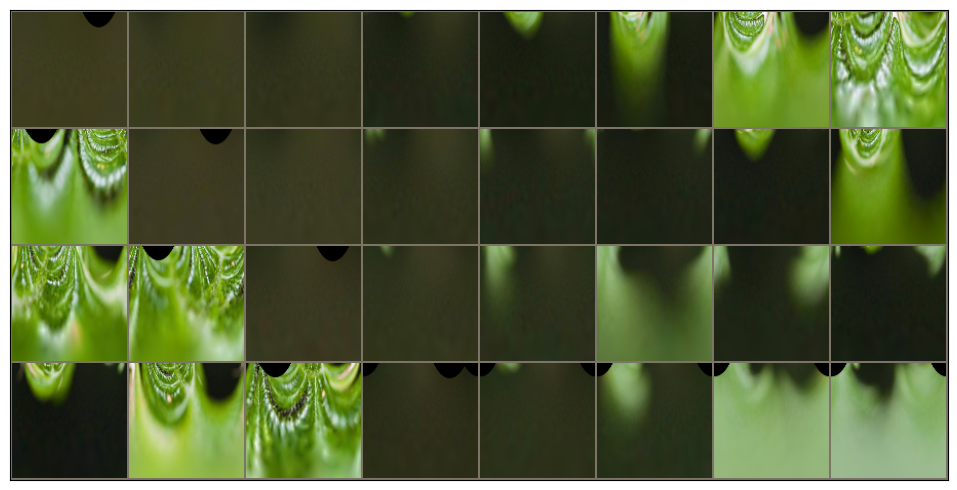

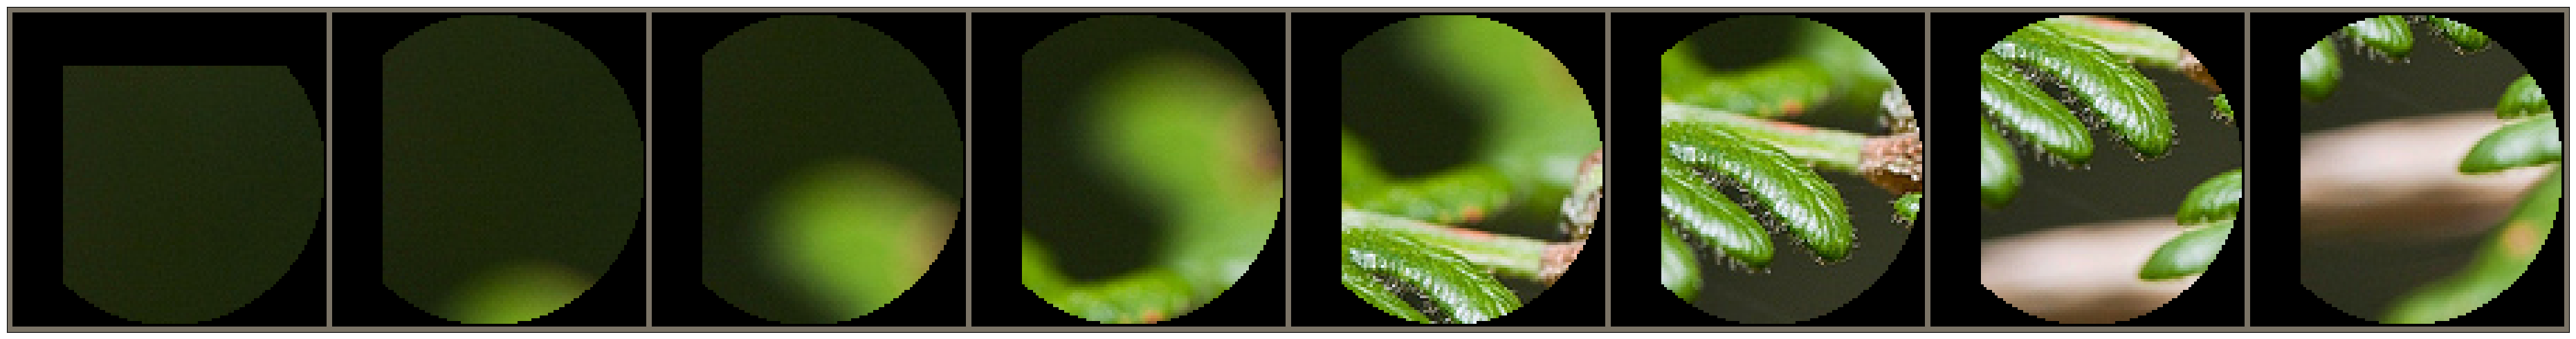

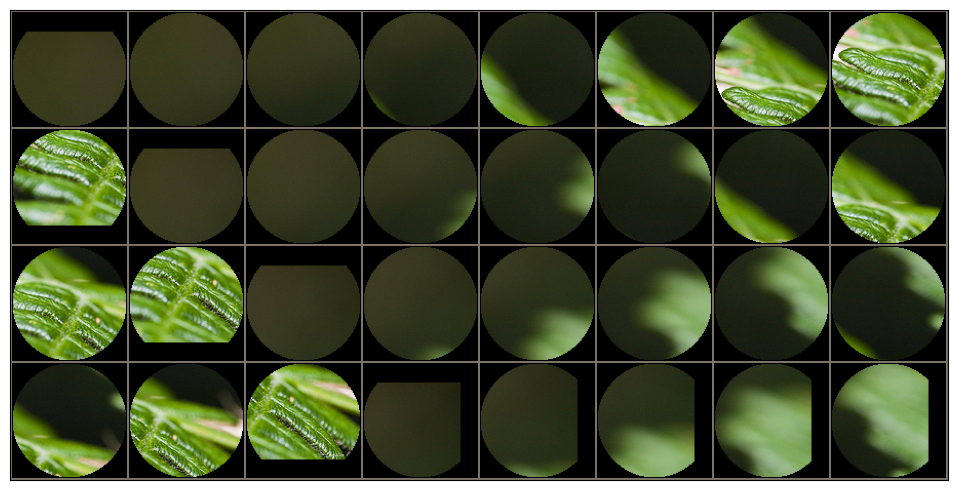

In [16]:
for do_polar in [True, False]:
    print(f'{do_polar=}')
    args.image_size = box_size
    args.do_polar = do_polar
    data_transform = get_transforms(args)
    cropped_images = torch.empty((N_fixations, 3, box_size, box_size))
    for i_fixation, (h, w) in enumerate(zip(pos_H.ravel(), pos_W.ravel())):
        h, w = int(h), int(w)
        # cropped_image = full_image[:, h-box_size//2:h+box_size//2, w-box_size//2:w+box_size//2]
        cropped_image = crop(full_image, h-box_size//2, w-box_size//2, box_size, box_size)
        cropped_images[i_fixation, ...] = data_transform(cropped_image)
    imshow(cropped_images[0:8, ...])
    imshow(cropped_images[72:104, ...])
    plt.show()

In [17]:
h, w

(337, 461)

In [18]:
cropped_images[12:36, ...].mean(axis=(1,2,3))

tensor([-0.831, -0.425, -0.485, -0.461, -0.459, -0.585, -1.661, -1.609, -1.338, -0.582, -0.074, -0.167, -0.376, -0.197, -0.521, -1.628,
        -1.558, -1.406, -0.566, -0.023, -0.094, -0.271, -0.304, -0.781])

In [19]:
outputs = {}
with torch.no_grad():
    data_set_type = 'focus'
    model_name = 'resnet101'
    for do_polar in [True, False]:
        print(f'{do_polar=}')
        args.image_size = box_size
        args.do_polar = do_polar
        data_transform = get_transforms(args)
        cropped_images = torch.empty((N_fixations, 3, box_size, box_size))
        for i_fixation, (h, w) in enumerate(zip(pos_H.ravel(), pos_W.ravel())):
            h, w = int(h), int(w)
            cropped_image = crop(full_image, h-box_size//2, w-box_size//2, box_size, box_size)
            cropped_images[i_fixation, ...] = data_transform(cropped_image)

        model_filename = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '.pt'

        print(f"Loading pre-trained resnet {model_filename}")
        model = charge_model(model_name=model_name, model_path=model_filename, 
                             do_circular=args.do_polar).to(device).eval()

        cropped_images = cropped_images.to(device)

        outputs[do_polar] = torch.nn.functional.softmax(model(cropped_images), dim=1)


do_polar=True
Loading pre-trained resnet cached_data/2024-05-14_focus_resnet101_do_polar=True.pt
loading .... cached_data/2024-05-14_focus_resnet101_do_polar=True.pt
do_polar=False
Loading pre-trained resnet cached_data/2024-05-14_focus_resnet101_do_polar=False.pt
loading .... cached_data/2024-05-14_focus_resnet101_do_polar=False.pt


In [20]:
outputs[False].shape

torch.Size([108, 1000])

In [21]:
for do_polar in [True, False]:
    probas, preds = torch.max(outputs[do_polar], dim=1)
    # detect = (preds == labels.data).cpu().numpy()
    for proba, pred in zip(probas, preds):
        print(f'{proba.item():.3f},\t\t\t\t {labels[pred]}')

0.326,				 nematode
0.307,				 tennis_ball
0.497,				 granny_smith
0.448,				 leaf_beetle
0.737,				 vine_snake
0.984,				 pineapple
0.495,				 hip
0.993,				 pot
0.994,				 pot
0.182,				 leaf_beetle
0.319,				 tennis_ball
0.233,				 lycaenid
0.904,				 lycaenid
1.000,				 boa_constrictor
0.753,				 grasshopper
0.575,				 tree_frog
0.284,				 eft
0.329,				 green_snake
0.195,				 vine_snake
0.637,				 ping-pong_ball
0.234,				 leaf_beetle
0.656,				 tree_frog
0.826,				 tree_frog
0.839,				 tree_frog
0.979,				 green_mamba
0.178,				 green_snake
0.170,				 zucchini
0.321,				 lycaenid
0.176,				 agama
0.263,				 thunder_snake
0.733,				 tree_frog
0.853,				 tree_frog
0.937,				 tree_frog
0.859,				 tree_frog
0.262,				 slug
0.646,				 leaf_beetle
0.204,				 leaf_beetle
0.167,				 agama
0.823,				 agama
0.608,				 tree_frog
0.740,				 tree_frog
0.985,				 tree_frog
0.960,				 tree_frog
0.391,				 grasshopper
0.725,				 broccoli
0.332,				 lycaenid
0.172,				 lycaenid
0.275,				 humming

In [22]:
outputs[True].shape

torch.Size([108, 1000])

In [23]:
# for pred in preds:
#     print(labels[pred])

In [24]:
labels[i_labels_dico[true_label]]

'tree_frog'

In [25]:
labels_dico[true_label], i_labels_dico[true_label]

('n01644373', 31)

In [26]:
proba_label = outputs[True][:, i_labels_dico[true_label]].detach().cpu().numpy()
proba_label

array([8.8920118e-03, 9.9810390e-03, 3.9277016e-03, 1.2510549e-02,
       2.0607749e-04, 3.7505305e-07, 1.3461583e-05, 6.5992552e-08,
       1.6848186e-05, 7.9953549e-03, 1.1200148e-02, 6.5504033e-03,
       5.5319006e-03, 2.3026496e-07, 4.1568764e-02, 5.7451695e-01,
       4.7477968e-02, 1.5155296e-02, 1.0814388e-02, 1.0428660e-04,
       7.4717384e-03, 6.5577990e-01, 8.2611889e-01, 8.3932257e-01,
       2.0333014e-06, 1.6051337e-02, 5.0461791e-02, 4.9424786e-03,
       3.9312057e-03, 2.3972713e-03, 7.3318166e-01, 8.5326344e-01,
       9.3713737e-01, 8.5924006e-01, 2.5945475e-02, 3.7493338e-03,
       8.4447097e-03, 3.4246000e-03, 1.2075260e-03, 6.0773087e-01,
       7.4008083e-01, 9.8460490e-01, 9.6030778e-01, 3.4852696e-03,
       2.6025096e-01, 2.9145766e-03, 2.0815071e-03, 3.2930043e-02,
       8.3967042e-01, 9.0797633e-01, 9.9680734e-01, 3.0545035e-04,
       6.5938610e-07, 1.1776590e-03, 6.0373386e-03, 7.4379859e-03,
       7.6811067e-03, 7.2344756e-03, 9.8259950e-01, 9.4417006e

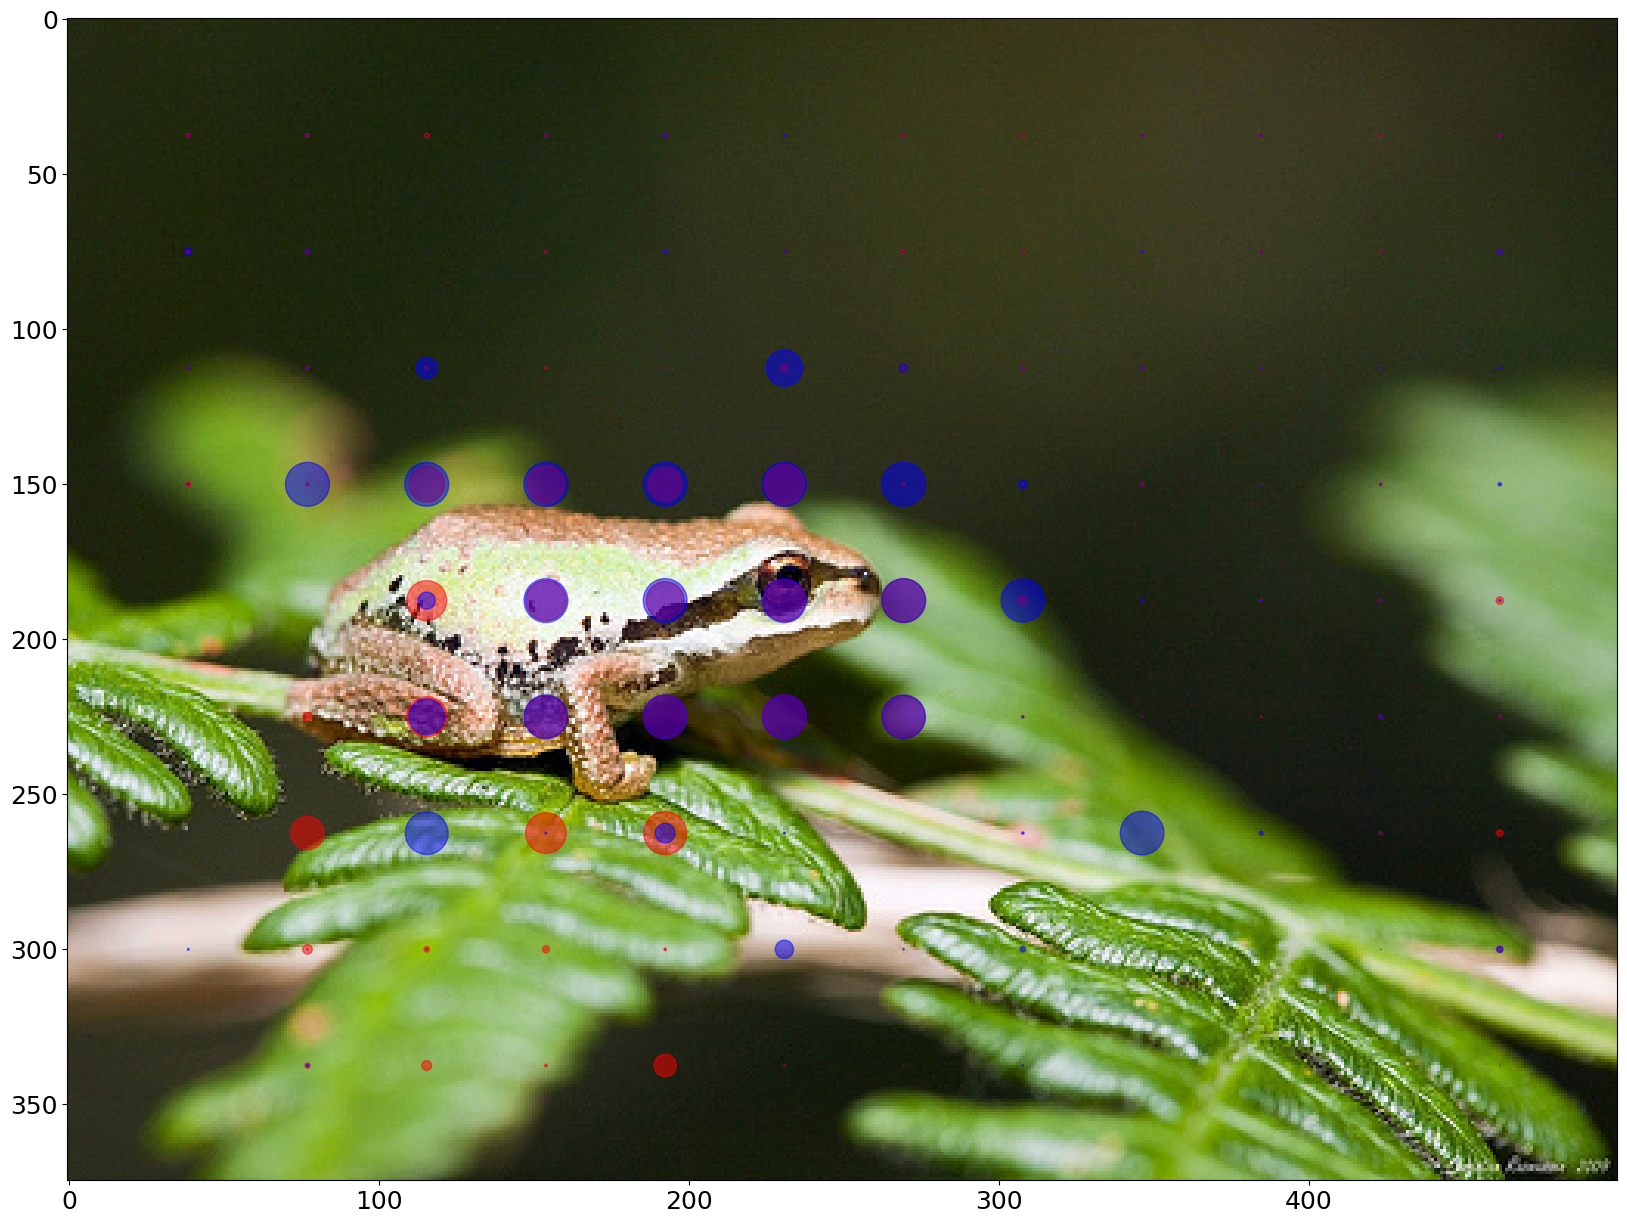

In [27]:
fig, ax = plt.subplots(figsize=(fig_width, fig_width))
ax.imshow(full_image_np)
# ax.set_xticks([])
for do_polar in [True, False]:
    proba_label = outputs[do_polar][:, i_labels_dico[true_label]].detach().cpu().numpy()
    ax.scatter(pos_W.ravel(), pos_H.ravel(), s=proba_label*1000, c='r' if do_polar else 'b', alpha=alpha)
# ax.scatter(500, 100, s=1000, c='r')
# ax.set_yticks([])  
fig.set_facecolor(color='white')

## as a function

In [28]:
N_fixations, N_batch = 100, 32

In [29]:
for idx in np.arange(0, N_fixations, N_batch):
    print(idx, np.min((idx+N_batch, N_fixations)))

0 32
32 64
64 96
96 100


### comparing mappings

In [30]:
data_set_type = 'focus'
model_name = 'resnet101'


In [31]:

outputs = {}
for do_polar in [True, False]:
    print(f'{do_polar=}')
    args.image_size = box_size
    args.do_polar = do_polar

    model_filename = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '.pt'

    print(f"Loading pre-trained resnet {model_filename}")
    model = charge_model(model_name=model_name, model_path=model_filename, 
                         do_circular=args.do_polar).to(device).eval()
    
    pos_H, pos_W, outputs[do_polar] = compute_likelihood_map(args, model, full_image)


do_polar=True
Loading pre-trained resnet cached_data/2024-05-14_focus_resnet101_do_polar=True.pt
loading .... cached_data/2024-05-14_focus_resnet101_do_polar=True.pt
do_polar=False
Loading pre-trained resnet cached_data/2024-05-14_focus_resnet101_do_polar=False.pt
loading .... cached_data/2024-05-14_focus_resnet101_do_polar=False.pt


In [32]:
outputs[True].shape, pos_H.shape

((121, 1000), (11, 11))

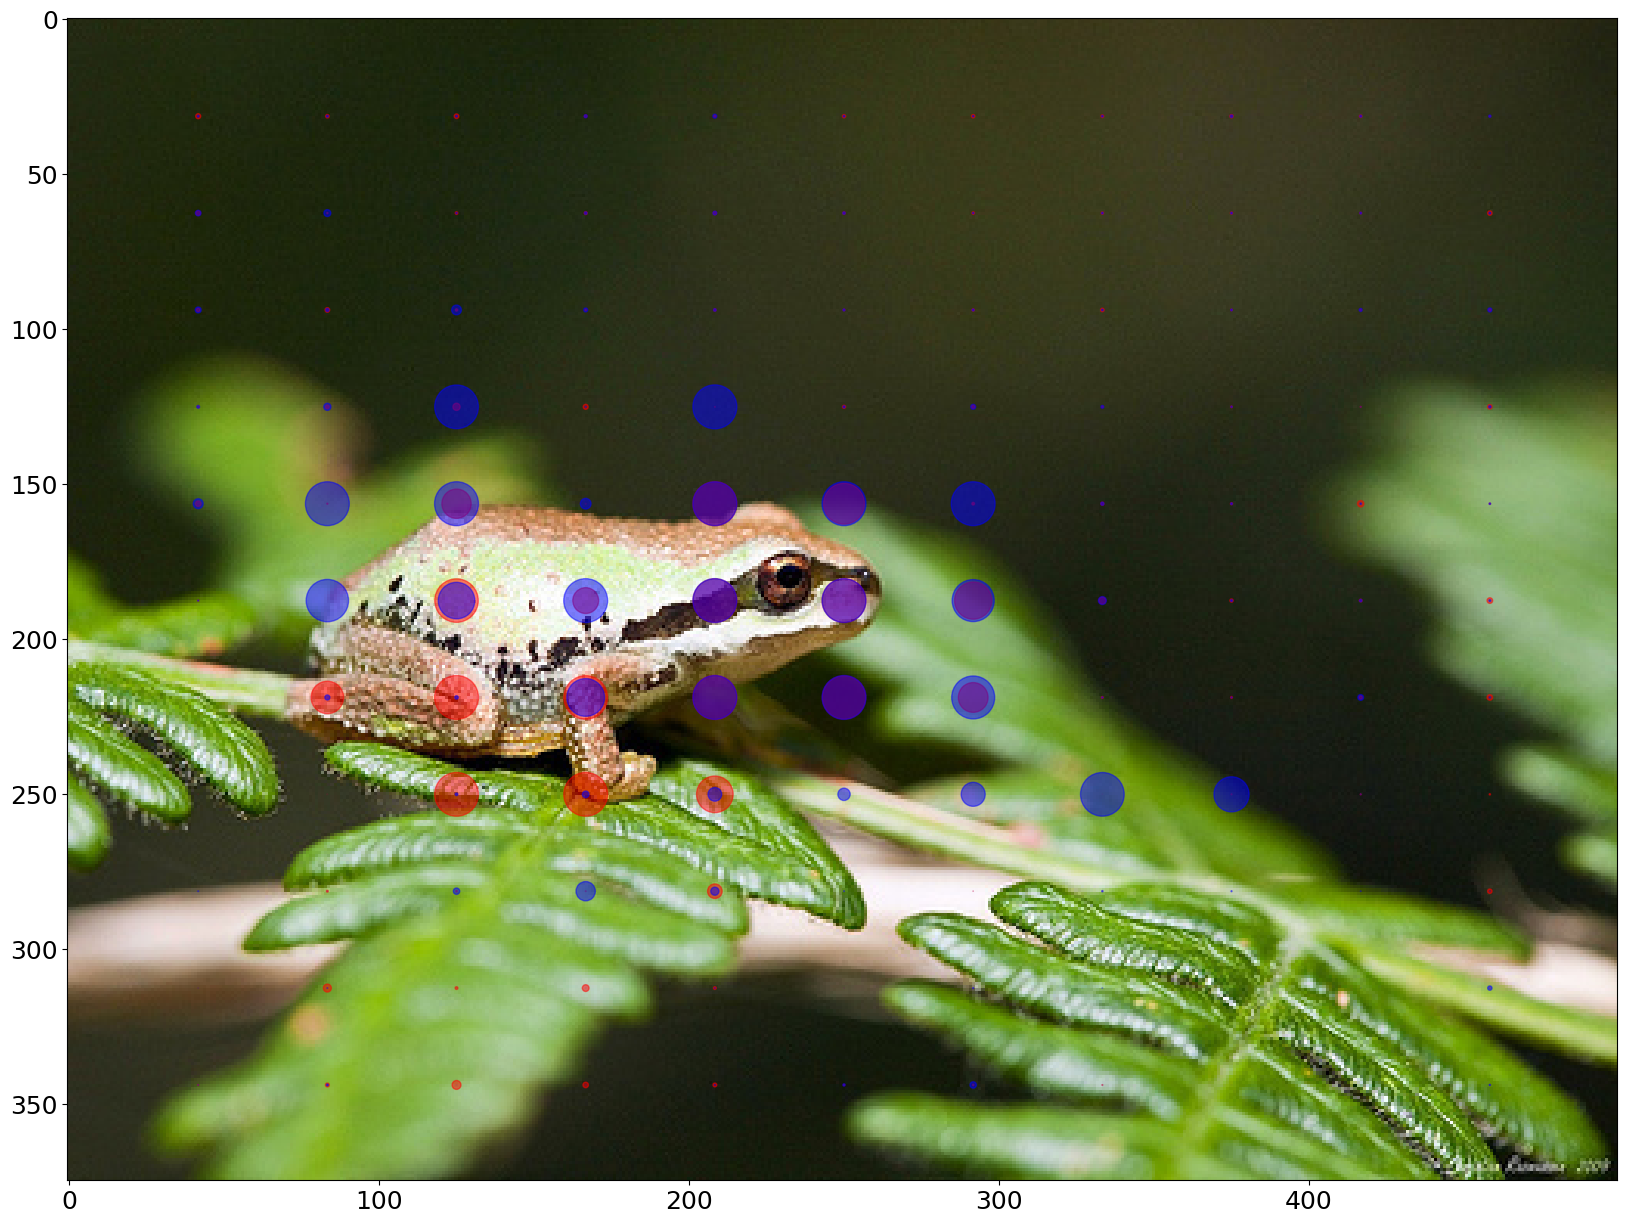

In [33]:
fig, ax = plt.subplots(figsize=(fig_width, fig_width))
ax.imshow(full_image_np)
# ax.set_xticks([])
for do_polar in [True, False]:
    proba_label = outputs[do_polar][:, i_labels_dico[true_label]]
    ax.scatter(pos_W.ravel(), pos_H.ravel(), s=proba_label*1000, c='r' if do_polar else 'b', alpha=alpha)
# ax.scatter(500, 100, s=1000, c='r')
# ax.set_yticks([])  
fig.set_facecolor(color='white')

### comparing methods

In [34]:
data_set_type = 'focus'
model_name = 'resnet101'
do_polar = True

outputs = {}
for method in ['full', 'valid']:
    print(f'{method=}')
    args.image_size = box_size
    args.do_polar = do_polar

    model_filename = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '.pt'

    print(f"Loading pre-trained resnet {model_filename}")
    model = charge_model(model_name=model_name, model_path=model_filename, 
                         do_circular=args.do_polar).to(device).eval()
    
    N_fixations = np.prod(resolution)
    aspect_ratio = full_image.shape[1]/full_image.shape[2]
    resolution_ = (int(np.sqrt(N_fixations*aspect_ratio)),
                    int(np.sqrt(N_fixations/aspect_ratio)))

    pos_H, pos_W, outputs[method] = compute_likelihood_map(args, model, full_image, resolution=resolution_, method=method)
    print(pos_W.ravel().shape, pos_H.ravel().shape, outputs[method].shape)


method='full'
Loading pre-trained resnet cached_data/2024-05-14_focus_resnet101_do_polar=True.pt
loading .... cached_data/2024-05-14_focus_resnet101_do_polar=True.pt
(108,) (108,) (108, 1000)
method='valid'
Loading pre-trained resnet cached_data/2024-05-14_focus_resnet101_do_polar=True.pt
loading .... cached_data/2024-05-14_focus_resnet101_do_polar=True.pt
(108,) (108,) (108, 1000)


In [35]:
resolution_

(9, 12)

(108,) (108,) (108,)
(108,) (108,) (108,)


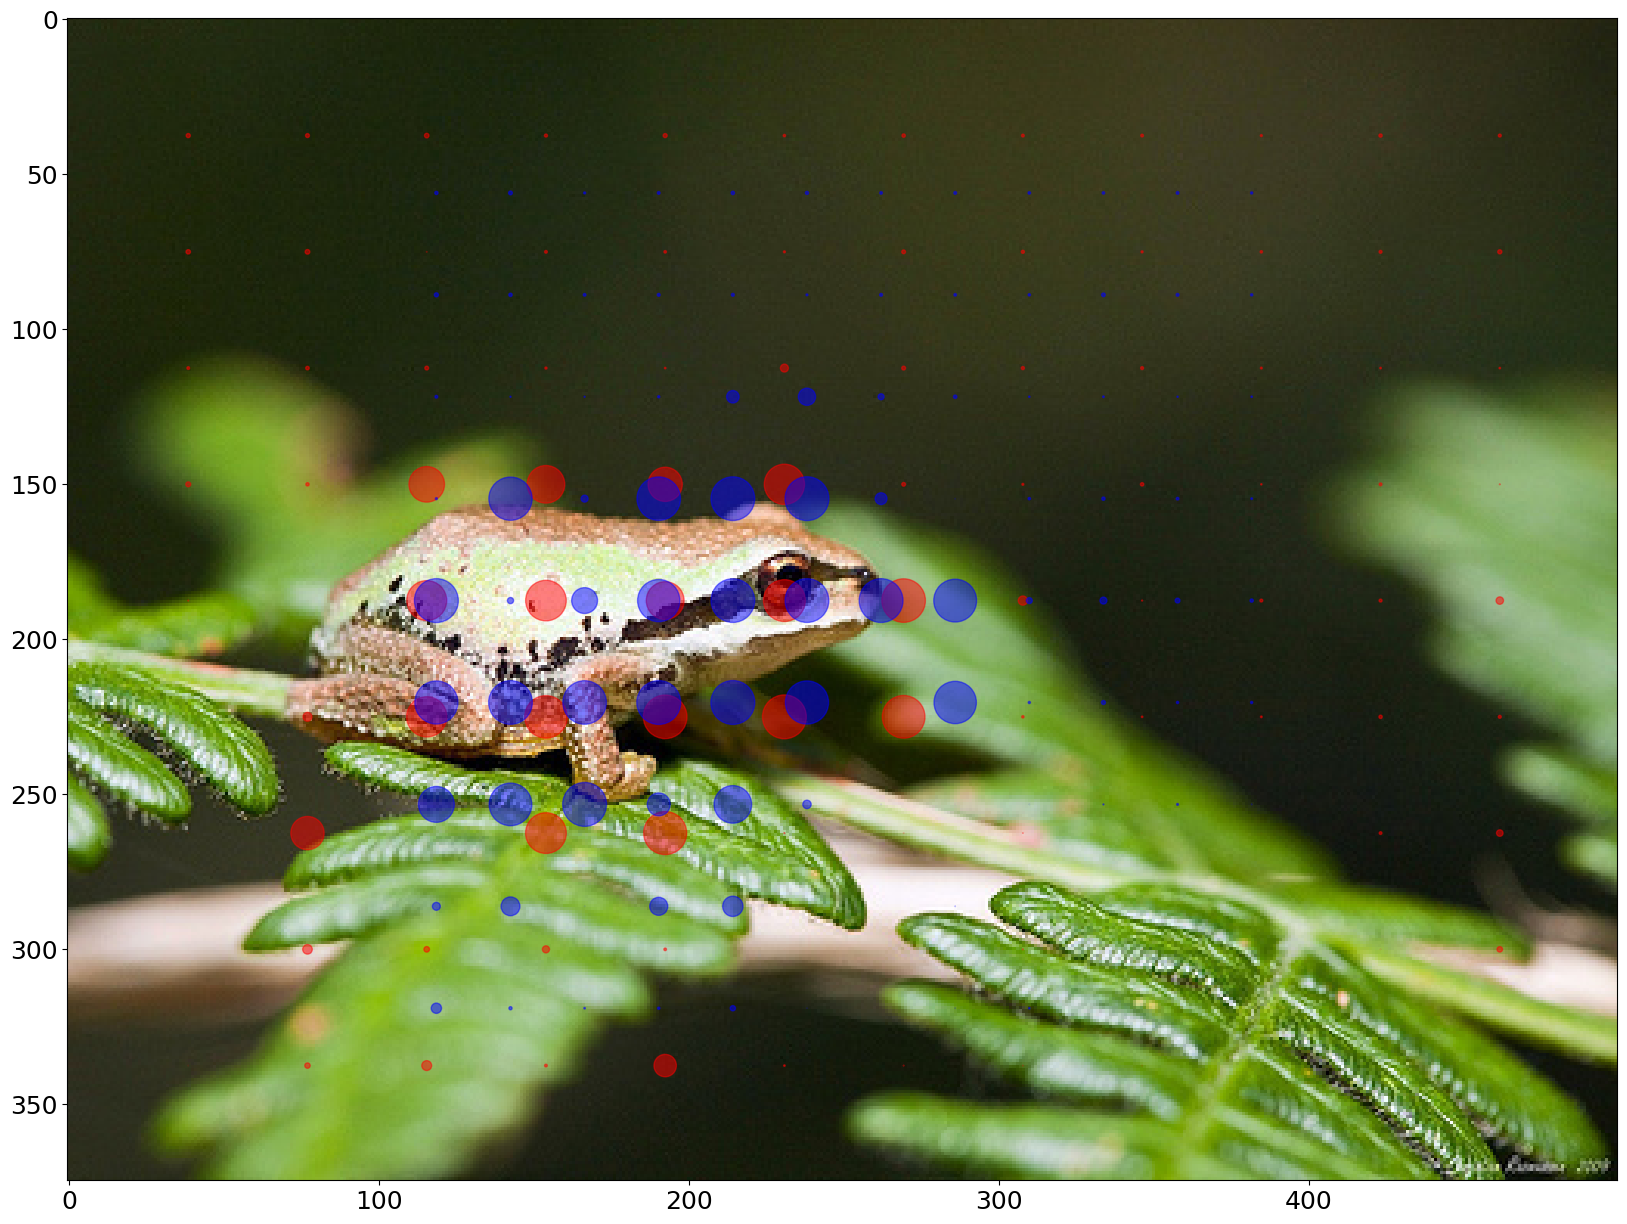

In [36]:
fig, ax = plt.subplots(figsize=(fig_width, fig_width))
ax.imshow(full_image_np)
# ax.set_xticks([])
for method in ['full', 'valid']:
    if method=='full':
        resolution_ = (int(np.sqrt(N_fixations*aspect_ratio)),int(np.sqrt(N_fixations/aspect_ratio)))
    else: 
        resolution_ = resolution

    pos_H, pos_W, box_size = get_positions(full_image, resolution_, size_ratio, method=method)
    proba_label = outputs[method][:, i_labels_dico[true_label]]
    print(pos_W.ravel().shape, pos_H.ravel().shape, proba_label.shape)
    ax.scatter(pos_W.ravel(), pos_H.ravel(), s=proba_label*1000, c='orange' if method=='full' else 'green', alpha=alpha)
# ax.scatter(500, 100, s=1000, c='r')
# ax.set_yticks([])  
fig.set_facecolor(color='white')

In [37]:
outputs

{'full': array([[5.76814773e-06, 2.26000266e-04, 3.25008186e-05, ...,
         2.37628028e-05, 2.83582222e-06, 5.09387907e-03],
        [1.01186323e-07, 7.83574251e-06, 2.43315782e-07, ...,
         1.04309156e-05, 1.23126244e-06, 6.38277253e-09],
        [1.50505656e-07, 8.29787678e-06, 4.63903206e-07, ...,
         2.03935615e-05, 4.73365844e-06, 6.65303901e-09],
        ...,
        [7.83083942e-06, 5.61973284e-05, 1.58982891e-06, ...,
         7.86707315e-05, 4.36482696e-05, 3.33589512e-08],
        [9.64684599e-09, 3.07355577e-07, 2.11686069e-09, ...,
         5.79178554e-08, 1.48179806e-05, 2.71293402e-07],
        [6.40220876e-10, 6.08396056e-10, 2.14402163e-10, ...,
         7.57267971e-10, 9.49909307e-08, 1.09122059e-10]]),
 'valid': array([[7.11277107e-06, 5.19178458e-04, 7.07204963e-05, ...,
         3.91572721e-05, 5.90596346e-06, 3.53937328e-04],
        [7.51056348e-07, 2.41292382e-05, 1.33184881e-06, ...,
         3.59271653e-05, 9.60201305e-06, 2.35433362e-08],
        